## 1. Setup

In [ ]:
!pip install ultralytics opencv-python-headless -q
import ultralytics
ultralytics.checks()


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, zipfile, shutil

ZIP_PATH = "/content/drive/MyDrive/FracAtlas.zip"   # <-- EDIT: path to your uploaded zip
LOCAL_ZIP_PATH = "/content/FracAtlas.zip"            # local copy -- avoids Drive-mount seek errors on extract
EXTRACT_TO = "/content"                              # extract locally, NOT into a Drive-mounted path

if os.path.exists(ZIP_PATH):
    print("Copying zip from Drive to local disk (avoids extraction errors on the Drive mount)...")
    shutil.copy(ZIP_PATH, LOCAL_ZIP_PATH)
    print("Extracting locally... (this can take a few minutes for ~4,000 files)")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO)
    print("Done. Check that a 'FracAtlas' folder now exists at:", EXTRACT_TO)
else:
    print(f"No zip found at {ZIP_PATH} -- skipping. "
          f"(This is fine if you already uploaded an extracted folder instead.)")


Copying zip from Drive to local disk (avoids extraction errors on the Drive mount)...
Extracting locally... (this can take a few minutes for ~4,000 files)
Done. Check that a 'FracAtlas' folder now exists at: /content


In [ ]:
import os, glob, shutil
import pandas as pd

RAW_ROOT = "/content/FracAtlas"                # <-- matches local extraction above; edit if different
PREPARED_ROOT = "/content/FracAtlas_yolo"       # <-- kept local too, for the same Drive-mount seek reasons

RAW_FRACTURED_DIR     = os.path.join(RAW_ROOT, "images/Fractured")
RAW_NONFRACTURED_DIR  = os.path.join(RAW_ROOT, "images/Non_fractured")
RAW_YOLO_LABEL_DIR    = os.path.join(RAW_ROOT, "Annotations/YOLO")
RAW_UTILITIES_DIR     = os.path.join(RAW_ROOT, "Utilities", "Fracture Split")   # <-- EDIT if your split CSVs live elsewhere

SPLIT_CSVS = {
    "train": os.path.join(RAW_UTILITIES_DIR, "train.csv"),
    "val":   os.path.join(RAW_UTILITIES_DIR, "valid.csv"),
    "test":  os.path.join(RAW_UTILITIES_DIR, "test.csv"),
}

for p in [RAW_FRACTURED_DIR, RAW_NONFRACTURED_DIR, RAW_YOLO_LABEL_DIR, *SPLIT_CSVS.values()]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING (check your folder/file names & paths)")


/content/FracAtlas/images/Fractured -> OK
/content/FracAtlas/images/Non_fractured -> OK
/content/FracAtlas/Annotations/YOLO -> OK
/content/FracAtlas/Utilities/Fracture Split/train.csv -> OK
/content/FracAtlas/Utilities/Fracture Split/valid.csv -> OK
/content/FracAtlas/Utilities/Fracture Split/test.csv -> OK


In [ ]:
# Build a lookup: filename -> (full image path, is_fractured)
# so we can resolve each image_id from the split CSVs regardless of which
# class folder it actually lives in.
image_lookup = {}
for img_path in glob.glob(os.path.join(RAW_FRACTURED_DIR, "*")):
    image_lookup[os.path.basename(img_path)] = (img_path, True)
for img_path in glob.glob(os.path.join(RAW_NONFRACTURED_DIR, "*")):
    image_lookup[os.path.basename(img_path)] = (img_path, False)

print(f"Total images indexed: {len(image_lookup)}")


Total images indexed: 4083


In [ ]:
def load_split(csv_path):
    df = pd.read_csv(csv_path)
    # tolerate slightly different column naming/casing
    id_col = [c for c in df.columns if c.strip().lower() in ("image_id", "imageid", "image id")]
    assert id_col, f"Couldn't find an image_id-like column in {csv_path}. Found columns: {list(df.columns)}"
    id_col = id_col[0]

    items = []
    missing = []
    for image_id in df[id_col].astype(str):
        image_id = image_id.strip()
        if image_id not in image_lookup:
            missing.append(image_id)
            continue
        img_path, is_fractured = image_lookup[image_id]
        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(RAW_YOLO_LABEL_DIR, base + ".txt")
        items.append((img_path, label_path if os.path.exists(label_path) else None, is_fractured))

    if missing:
        print(f"  WARNING: {len(missing)} image_id(s) in {os.path.basename(csv_path)} "
              f"were not found in images/Fractured or images/Non_fractured. "
              f"First few: {missing[:5]}")
    return items

train_items = load_split(SPLIT_CSVS["train"])
val_items   = load_split(SPLIT_CSVS["val"])
test_items  = load_split(SPLIT_CSVS["test"])

def summarize(items, name):
    n_frac = sum(1 for _, _, f in items if f)
    n_nonfrac = len(items) - n_frac
    n_labeled = sum(1 for _, l, f in items if f and l)
    print(f"{name}: {len(items)} images ({n_frac} fractured / {n_nonfrac} non-fractured) "
          f"-- {n_labeled}/{n_frac} fractured images have a YOLO label file")

summarize(train_items, "Train")
summarize(val_items, "Val")
summarize(test_items, "Test")


Train: 574 images (574 fractured / 0 non-fractured) -- 574/574 fractured images have a YOLO label file
Val: 82 images (82 fractured / 0 non-fractured) -- 82/82 fractured images have a YOLO label file
Test: 63 images (61 fractured / 2 non-fractured) -- 61/61 fractured images have a YOLO label file


In [ ]:
def materialize_split(items, split_name):
    img_out = os.path.join(PREPARED_ROOT, "images", split_name)
    lbl_out = os.path.join(PREPARED_ROOT, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for img_path, label_path, is_fractured in items:
        shutil.copy(img_path, os.path.join(img_out, os.path.basename(img_path)))
        base = os.path.splitext(os.path.basename(img_path))[0]
        dst_label = os.path.join(lbl_out, base + ".txt")
        if label_path:
            shutil.copy(label_path, dst_label)
        else:
            # Non-fractured (or fractured-but-unlabeled) image -> empty label file = background
            open(dst_label, "w").close()

materialize_split(train_items, "train")
materialize_split(val_items, "val")
materialize_split(test_items, "test")
print("Dataset prepared at:", PREPARED_ROOT)


Dataset prepared at: /content/FracAtlas_yolo


## 3. Config



In [ ]:
import os

DATASET_ROOT = PREPARED_ROOT   # points at the folder we just built
CLASSES = ["fracture"]  # edit if you have more than one class (e.g. hairline vs displaced)

IMG_TRAIN = os.path.join(DATASET_ROOT, "images/train")
IMG_VAL   = os.path.join(DATASET_ROOT, "images/val")
IMG_TEST  = os.path.join(DATASET_ROOT, "images/test")
LBL_TRAIN = os.path.join(DATASET_ROOT, "labels/train")
LBL_VAL   = os.path.join(DATASET_ROOT, "labels/val")
LBL_TEST  = os.path.join(DATASET_ROOT, "labels/test")

for p in [IMG_TRAIN, IMG_VAL, IMG_TEST, LBL_TRAIN, LBL_VAL, LBL_TEST]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING")


/content/FracAtlas_yolo/images/train -> OK
/content/FracAtlas_yolo/images/val -> OK
/content/FracAtlas_yolo/images/test -> OK
/content/FracAtlas_yolo/labels/train -> OK
/content/FracAtlas_yolo/labels/val -> OK
/content/FracAtlas_yolo/labels/test -> OK


## 4. Boost the training set with true-negative backgrounds



In [ ]:
import random

random.seed(42)

NEG_TO_POS_RATIO = 1.0  # negatives added : positive train images. Keep <=1-2x --
                         # too many pure backgrounds can suppress recall, which is
                         # already your bottleneck. Tune this if you want to experiment.

# Basenames already used in val/test (from the 'resolved' dict built in Section 2) --
# exclude these from the negative pool to prevent leakage

# Define 'resolved' using the previously loaded val_items and test_items
resolved = {
    "val": val_items,
    "test": test_items
}

used_elsewhere = set()
for split_name in ["val", "test"]:
    for img_path, _, _ in resolved[split_name]: # Accessing the first element (img_path)
        used_elsewhere.add(os.path.basename(img_path))

all_nonfractured = glob.glob(os.path.join(RAW_NONFRACTURED_DIR, "*"))
candidate_negatives = [p for p in all_nonfractured if os.path.basename(p) not in used_elsewhere]
random.shuffle(candidate_negatives)

n_train_positives = len(glob.glob(os.path.join(PREPARED_ROOT, "images/train/*")))
n_negatives_to_add = min(int(n_train_positives * NEG_TO_POS_RATIO), len(candidate_negatives))
negatives_to_add = candidate_negatives[:n_negatives_to_add]

train_img_out = os.path.join(PREPARED_ROOT, "images/train")
train_lbl_out = os.path.join(PREPARED_ROOT, "labels/train")
for img_path in negatives_to_add:
    shutil.copy(img_path, os.path.join(train_img_out, os.path.basename(img_path)))
    base = os.path.splitext(os.path.basename(img_path))[0]
    open(os.path.join(train_lbl_out, base + ".txt"), "w").close()  # empty = background

print(f"Available true-negative pool (excluding val/test): {len(candidate_negatives)}")
print(f"Added {len(negatives_to_add)} background negatives to train "
      f"(ratio {len(negatives_to_add)/max(n_train_positives,1):.2f}:1 vs {n_train_positives} positives)")
print(f"New train set size: {n_train_positives + len(negatives_to_add)} images")

Available true-negative pool (excluding val/test): 3364
Added 574 background negatives to train (ratio 1.00:1 vs 574 positives)
New train set size: 1148 images


## 5. Dataset audit — class balance & bbox size distribution


In [ ]:
import glob
from collections import Counter
import numpy as np

def audit_split(label_dir, img_dir, split_name):
    label_files = glob.glob(os.path.join(label_dir, "*.txt"))
    n_images = len(glob.glob(os.path.join(img_dir, "*")))
    n_with_boxes = 0
    n_boxes = 0
    box_areas = []  # normalized area (w*h), used to bucket small/medium/large
    class_counts = Counter()

    for lf in label_files:
        with open(lf) as f:
            lines = [l.strip() for l in f if l.strip()]
        if lines:
            n_with_boxes += 1
        for line in lines:
            parts = line.split()
            cls = int(parts[0])
            w, h = float(parts[3]), float(parts[4])
            box_areas.append(w * h)
            class_counts[cls] += 1
            n_boxes += 1

    print(f"--- {split_name} ---")
    print(f"Images: {n_images} | Images with >=1 fracture box: {n_with_boxes} "
          f"({100*n_with_boxes/max(n_images,1):.1f}%)")
    print(f"Total boxes: {n_boxes}")
    print(f"Class counts: {dict(class_counts)}")
    if box_areas:
        box_areas = np.array(box_areas)
        small  = (box_areas < 0.02).sum()
        medium = ((box_areas >= 0.02) & (box_areas < 0.1)).sum()
        large  = (box_areas >= 0.1).sum()
        print(f"Bbox size buckets -> small(hairline-like): {small}, medium: {medium}, large: {large}")
    print()
    return n_images, n_with_boxes, n_boxes, class_counts

train_stats = audit_split(LBL_TRAIN, IMG_TRAIN, "train")
val_stats   = audit_split(LBL_VAL, IMG_VAL, "val")
test_stats  = audit_split(LBL_TEST, IMG_TEST, "test")

# Imbalance ratio -- write this number down, quote it in your project README/resume talking points
n_images, n_with_boxes, _, _ = train_stats
print(f"Positive (fracture) rate in train: {100*n_with_boxes/n_images:.1f}% "
      f"-> imbalance ratio ~1:{ (n_images-n_with_boxes)/max(n_with_boxes,1):.1f} (fracture:non-fracture)")


--- train ---
Images: 1148 | Images with >=1 fracture box: 574 (50.0%)
Total boxes: 764
Class counts: {0: 764}
Bbox size buckets -> small(hairline-like): 719, medium: 45, large: 0

--- val ---
Images: 82 | Images with >=1 fracture box: 82 (100.0%)
Total boxes: 91
Class counts: {0: 91}
Bbox size buckets -> small(hairline-like): 83, medium: 8, large: 0

--- test ---
Images: 63 | Images with >=1 fracture box: 63 (100.0%)
Total boxes: 69
Class counts: {0: 69}
Bbox size buckets -> small(hairline-like): 64, medium: 5, large: 0

Positive (fracture) rate in train: 50.0% -> imbalance ratio ~1:1.0 (fracture:non-fracture)


## 6. Class imbalance handling




In [ ]:
def build_oversampled_basenames(img_dir, lbl_dir, oversample_factor=3):
    """Return a list of basenames where fracture-positive images are
    repeated oversample_factor times relative to negative (background) images."""
    all_imgs = glob.glob(os.path.join(img_dir, "*"))
    pos, neg = [], []
    for img_path in all_imgs:
        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        if os.path.exists(lbl_path) and open(lbl_path).read().strip():
            pos.append(os.path.basename(img_path))
        else:
            neg.append(os.path.basename(img_path))
    oversampled = pos * oversample_factor + neg
    random.shuffle(oversampled)
    print(f"Original: {len(pos)} positive / {len(neg)} negative")
    print(f"After {oversample_factor}x oversampling: {len(pos)*oversample_factor} positive / {len(neg)} negative "
          f"(new ratio 1:{len(neg)/max(len(pos)*oversample_factor,1):.2f})")
    return oversampled

# Basenames only -- turned into full paths for each variant in Section 8
oversampled_basenames = build_oversampled_basenames(IMG_TRAIN, LBL_TRAIN, oversample_factor=3)
print(f"Oversampled list length: {len(oversampled_basenames)} (this is what BOTH variants will train on)")


Original: 574 positive / 574 negative
After 3x oversampling: 1722 positive / 574 negative (new ratio 1:0.33)
Oversampled list length: 2296 (this is what BOTH variants will train on)


## 7. CLAHE ablation — build a second, preprocessed copy of the dataset

In [ ]:
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import multiprocessing

CLAHE_ROOT = "/content/fracatlas_clahe"
DENOISE_TARGET_SIZE = 1024  # matches training imgsz -- no benefit denoising beyond this

def apply_clahe_denoise(img):
    # Resize first -- denoising cost scales with pixel count, and training will
    # downscale to DENOISE_TARGET_SIZE anyway, so working at full X-ray resolution wastes time
    h, w = img.shape[:2]
    scale = DENOISE_TARGET_SIZE / max(h, w)
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    # Work in LAB space so we only enhance contrast on the L channel
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    merged = cv2.merge((l_eq, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    # searchWindowSize reduced 21->11 -- roughly 4x fewer comparisons per pixel,
    # still meaningfully denoises X-ray sensor noise without being visually different
    denoised = cv2.fastNlMeansDenoisingColored(enhanced, None, h=6, hColor=6,
                                                templateWindowSize=7, searchWindowSize=11)
    return denoised

def _process_one(args):
    img_path, lbl_dir, out_img_dir, out_lbl_dir = args
    img = cv2.imread(img_path)
    if img is None:
        return
    processed = apply_clahe_denoise(img)
    out_path = os.path.join(out_img_dir, os.path.basename(img_path))
    cv2.imwrite(out_path, processed)

    base = os.path.splitext(os.path.basename(img_path))[0]
    src_lbl = os.path.join(lbl_dir, base + ".txt")
    dst_lbl = os.path.join(out_lbl_dir, base + ".txt")
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, dst_lbl)
    else:
        open(dst_lbl, "w").close()  # empty label file = no fracture

def build_clahe_split(img_dir, lbl_dir, split_name, max_workers=None):
    out_img_dir = os.path.join(CLAHE_ROOT, "images", split_name)
    out_lbl_dir = os.path.join(CLAHE_ROOT, "labels", split_name)
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    img_paths = glob.glob(os.path.join(img_dir, "*"))
    max_workers = max_workers or multiprocessing.cpu_count()
    tasks = [(p, lbl_dir, out_img_dir, out_lbl_dir) for p in img_paths]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        list(tqdm(executor.map(_process_one, tasks), total=len(tasks),
                   desc=f"CLAHE-processing {split_name} ({max_workers} workers)"))

print(f"CPU cores available: {multiprocessing.cpu_count()}")
build_clahe_split(IMG_TRAIN, LBL_TRAIN, "train")
build_clahe_split(IMG_VAL, LBL_VAL, "val")
build_clahe_split(IMG_TEST, LBL_TEST, "test")
print("CLAHE dataset ready at", CLAHE_ROOT)


CPU cores available: 2


CLAHE-processing test (2 workers): 100%|██████████| 63/63 [00:11<00:00,  5.30it/s]

CLAHE dataset ready at /content/fracatlas_clahe


## 8. Write data.yaml files for both variants


In [ ]:
def write_path_list(basenames, img_dir, out_path):
    paths = [os.path.join(img_dir, b) for b in basenames]
    with open(out_path, "w") as f:
        f.write("\n".join(paths))
    return out_path

baseline_train_list_path = write_path_list(
    oversampled_basenames, os.path.join(DATASET_ROOT, "images/train"),
    "/content/train_oversampled_baseline.txt",
)
clahe_train_list_path = write_path_list(
    oversampled_basenames, os.path.join(CLAHE_ROOT, "images/train"),
    "/content/train_oversampled_clahe.txt",
)
print(f"Baseline train list: {baseline_train_list_path} ({len(oversampled_basenames)} entries)")
print(f"CLAHE train list:    {clahe_train_list_path} ({len(oversampled_basenames)} entries)")
print("Both lists share identical basenames/multiplicities -- only preprocessing differs.")

def write_data_yaml(path, root, train_path, val_path, test_path):
    content = f"""path: {root}
train: {train_path}
val: {val_path}
test: {test_path}

nc: {len(CLASSES)}
names: {CLASSES}
"""
    with open(path, "w") as f:
        f.write(content)
    print(f"Wrote {path}")

# Baseline (no CLAHE) -- oversampled list, fixed composition
write_data_yaml(
    "/content/data_baseline.yaml",
    DATASET_ROOT,
    baseline_train_list_path,
    IMG_VAL,
    IMG_TEST,
)

# CLAHE variant -- SAME oversampled composition, just CLAHE-processed pixels
write_data_yaml(
    "/content/data_clahe.yaml",
    CLAHE_ROOT,
    clahe_train_list_path,
    "images/val",
    "images/test",
)


Baseline train list: /content/train_oversampled_baseline.txt (2296 entries)
CLAHE train list:    /content/train_oversampled_clahe.txt (2296 entries)
Both lists share identical basenames/multiplicities -- only preprocessing differs.
Wrote /content/data_baseline.yaml
Wrote /content/data_clahe.yaml


## 9. Train both models — across multiple seeds




In [ ]:
from ultralytics import YOLO

NUM_SEEDS = 3
SEEDS = [42, 123, 7][:NUM_SEEDS]

BASE_ARGS = dict(
    epochs=30,
    imgsz=1024,        # up from 640 -- small/hairline fractures need more input resolution to survive downsampling
    batch=8,            # reduced from 16 to fit larger imgsz in Colab GPU memory
    patience=15,       # early stopping
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.3,     # pastes fracture regions onto other images -- directly increases small-fracture exposure
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,   # helps generalize across X-ray exposure variation
    verbose=True,
)

baseline_models = {}
for seed in SEEDS:
    print(f"\n=== Training BASELINE, seed={seed} ===")
    model = YOLO("yolov8n.pt")
    model.train(
        data="/content/data_baseline.yaml",
        project="/content/runs",
        name=f"baseline_seed{seed}",
        seed=seed,
        **BASE_ARGS,
    )
    baseline_models[seed] = f"/content/runs/baseline_seed{seed}/weights/best.pt"
os.makedirs('/content/drive/MyDrive/fracture_weights', exist_ok=True)
shutil.copy(baseline_models[seed], f'/content/drive/MyDrive/fracture_weights/baseline_seed{seed}_best.pt')
print(f"Backed up seed {seed} to Drive")




=== Training BASELINE, seed=42 ===
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_baseline.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [15]:
clahe_models = {}
for seed in SEEDS:
    print(f"\n=== Training CLAHE variant, seed={seed} ===")
    model = YOLO("yolov8n.pt")
    model.train(
        data="/content/data_clahe.yaml",
        project="/content/runs",
        name=f"clahe_seed{seed}",
        seed=seed,
        **BASE_ARGS,
    )
    clahe_models[seed] = f"/content/runs/clahe_seed{seed}/weights/best.pt"





=== Training CLAHE variant, seed=42 ===
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_clahe.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

## 10. Evaluate both — mean ± std across seeds

In [16]:
import numpy as np

def evaluate_one(model_path, data_yaml):
    model = YOLO(model_path)
    metrics = model.val(data=data_yaml, split="test", verbose=False)
    return {
        "mAP@0.5": metrics.box.map50,
        "mAP@0.5:0.95": metrics.box.map,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
    }

def evaluate_across_seeds(models_dict, data_yaml, name):
    all_metrics = [evaluate_one(path, data_yaml) for path in models_dict.values()]
    keys = all_metrics[0].keys()
    summary = {k: (np.mean([m[k] for m in all_metrics]), np.std([m[k] for m in all_metrics])) for k in keys}
    print(f"\n=== {name} (n={len(models_dict)} seeds) ===")
    for k, (mean, std) in summary.items():
        print(f"{k:14s}: {mean:.4f} +/- {std:.4f}")
    return summary, all_metrics

summary_baseline, runs_baseline = evaluate_across_seeds(baseline_models, "/content/data_baseline.yaml", "Baseline (no CLAHE)")
summary_clahe, runs_clahe = evaluate_across_seeds(clahe_models, "/content/data_clahe.yaml", "CLAHE + Denoising")


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 17.8±4.9 MB/s, size: 17.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/FracAtlas_yolo/labels/test... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 1.2Kit/s 0.1s
val: New cache created: /content/FracAtlas_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.6s
                   all         63         69      0.774       0.42      0.553      0.232
Speed: 28.4ms preprocess, 13.1ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tes

In [17]:
import pandas as pd

rows = []
for metric in summary_baseline.keys():
    b_mean, b_std = summary_baseline[metric]
    c_mean, c_std = summary_clahe[metric]
    delta = c_mean - b_mean
    # Effect is only worth claiming if the delta clears the combined noise band
    noise_band = b_std + c_std
    verdict = "Real difference" if abs(delta) > noise_band else "Within noise -- not a reliable difference"
    rows.append({
        "Metric": metric,
        "Baseline (mean +/- std)": f"{b_mean:.4f} +/- {b_std:.4f}",
        "CLAHE (mean +/- std)": f"{c_mean:.4f} +/- {c_std:.4f}",
        "Delta": f"{delta:+.4f}",
        "Verdict": verdict,
    })

comparison = pd.DataFrame(rows)
comparison


,Metric,Baseline (mean +/- std),CLAHE (mean +/- std),Delta,Verdict
0,mAP@0.5,0.5167 +/- 0.0413,0.4571 +/- 0.0058,-0.0596,Real difference
1,mAP@0.5:0.95,0.2183 +/- 0.0198,0.1801 +/- 0.0083,-0.0382,Real difference
2,Precision,0.7058 +/- 0.0583,0.5965 +/- 0.0659,-0.1094,Within noise -- not a reliable difference
3,Recall,0.4493 +/- 0.0516,0.4225 +/- 0.0294,-0.0268,Within noise -- not a reliable difference


## 11. Inference latency benchmark


In [18]:
import time
import torch

def benchmark_latency(model_path, img_dir, n_samples=100, warmup=10):
    model = YOLO(model_path)
    img_paths = glob.glob(os.path.join(img_dir, "*"))[:n_samples + warmup]
    device_is_cuda = torch.cuda.is_available()

    for p in img_paths[:warmup]:
        _ = model.predict(p, verbose=False)
    if device_is_cuda:
        torch.cuda.synchronize()

    times = []
    for p in img_paths[warmup:]:
        if device_is_cuda:
            torch.cuda.synchronize()
        start = time.time()
        _ = model.predict(p, verbose=False)
        if device_is_cuda:
            torch.cuda.synchronize()
        times.append(time.time() - start)

    times = np.array(times)
    print(f"Mean latency: {times.mean()*1000:.1f} ms +/- {times.std()*1000:.1f} ms | "
          f"p95: {np.percentile(times, 95)*1000:.1f} ms | "
          f"FPS: {1/times.mean():.1f}")
    return times

print("Baseline model (seed=42):")
lat_baseline = benchmark_latency(baseline_models[42], IMG_TEST)
print("\nCLAHE model (seed=42):")
lat_clahe = benchmark_latency(clahe_models[42], os.path.join(CLAHE_ROOT, "images/test"))
print("\nNote: this times the forward pass only. It does NOT include CLAHE preprocessing time, "
      "which would need to be added separately for a real deployment latency estimate of the CLAHE variant.")


Baseline model (seed=42):
Mean latency: 12.2 ms +/- 1.4 ms | p95: 14.5 ms | FPS: 82.3

CLAHE model (seed=42):
Mean latency: 11.7 ms +/- 1.8 ms | p95: 13.9 ms | FPS: 85.4

Note: this times the forward pass only. It does NOT include CLAHE preprocessing time, which would need to be added separately for a real deployment latency estimate of the CLAHE variant.


## 12. Error analysis


In [19]:
CONF_THRESHOLD = 0.25   # stated explicitly -- change this and TP/FP/FN counts below will shift accordingly
IOU_THRESHOLD_FOR_MATCH = 0.5   # standard mAP@0.5 convention, used to decide if a prediction "matches" a GT box

use_clahe = summary_clahe["mAP@0.5"][0] >= summary_baseline["mAP@0.5"][0]

BEST_MODEL_PATH = clahe_models[42] if use_clahe else baseline_models[42]
BEST_TEST_IMG_DIR = (os.path.join(CLAHE_ROOT, "images/test") if use_clahe else IMG_TEST)
BEST_TEST_LBL_DIR = (os.path.join(CLAHE_ROOT, "labels/test") if use_clahe else LBL_TEST)
print(f"Using best model (by mean mAP@0.5 across seeds): "
      f"{'CLAHE variant' if use_clahe else 'Baseline'} -> {BEST_MODEL_PATH}")
print(f"Confidence threshold: {CONF_THRESHOLD} | IoU match threshold: {IOU_THRESHOLD_FOR_MATCH}")


Using best model (by mean mAP@0.5 across seeds): Baseline -> /content/runs/baseline_seed42/weights/best.pt
Confidence threshold: 0.25 | IoU match threshold: 0.5


In [20]:
def iou(box1, box2):
    # boxes in [x1,y1,x2,y2] format
    xa1, ya1, xa2, ya2 = box1
    xb1, yb1, xb2, yb2 = box2
    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0

def yolo_to_xyxy(line, img_w, img_h):
    parts = line.split()
    cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:5])
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [x1, y1, x2, y2], w * h  # also return normalized area for size bucketing

best_model = YOLO(BEST_MODEL_PATH)

false_negatives = []  # missed fracture cases: (img_path, gt_area)
false_positives = []  # predicted fracture where none exists
true_positives = 0

test_imgs = glob.glob(os.path.join(BEST_TEST_IMG_DIR, "*"))

for img_path in tqdm(test_imgs, desc="Error analysis"):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(BEST_TEST_LBL_DIR, base + ".txt")

    gt_boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                if line.strip():
                    box, area = yolo_to_xyxy(line, w, h)
                    gt_boxes.append((box, area))

    pred = best_model.predict(img_path, conf=CONF_THRESHOLD, verbose=False)[0]
    pred_boxes = [b.tolist() for b in pred.boxes.xyxy.cpu().numpy()] if len(pred.boxes) else []

    matched_gt = set()
    for pb in pred_boxes:
        best_iou, best_idx = 0, -1
        for i, (gb, _) in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            cur_iou = iou(pb, gb)
            if cur_iou > best_iou:
                best_iou, best_idx = cur_iou, i
        if best_iou >= IOU_THRESHOLD_FOR_MATCH:
            matched_gt.add(best_idx)
            true_positives += 1
        else:
            false_positives.append(img_path)

    for i, (gb, area) in enumerate(gt_boxes):
        if i not in matched_gt:
            false_negatives.append((img_path, area))

print(f"\nTrue positives: {true_positives}")
print(f"False positives: {len(false_positives)}")
print(f"False negatives (missed fractures): {len(false_negatives)}")


Error analysis: 100%|██████████| 63/63 [00:01<00:00, 57.10it/s]


True positives: 34
False positives: 20
False negatives (missed fractures): 35


In [21]:
# Break false negatives down by bbox size -- this is the number that lets you say
# "the model misses small/hairline fractures disproportionately more than large ones"
fn_areas = np.array([a for _, a in false_negatives])

if len(fn_areas):
    small_fn  = (fn_areas < 0.02).sum()
    medium_fn = ((fn_areas >= 0.02) & (fn_areas < 0.1)).sum()
    large_fn  = (fn_areas >= 0.1).sum()

    print("Missed fractures by size bucket:")
    print(f"  Small (hairline-like): {small_fn}")
    print(f"  Medium:                {medium_fn}")
    print(f"  Large:                 {large_fn}")

    # Compare against the overall size distribution from the audit step to see if
    # small fractures are being missed *disproportionately*, not just because there
    # are fewer of them
    total_small = (np.array([a for _, a in [(0,a) for a in fn_areas]]) < 0.02).sum()  # placeholder if needed
else:
    print("No false negatives found on this test set -- unusually clean result, double check your split.")


Missed fractures by size bucket:
  Small (hairline-like): 32
  Medium:                3
  Large:                 0


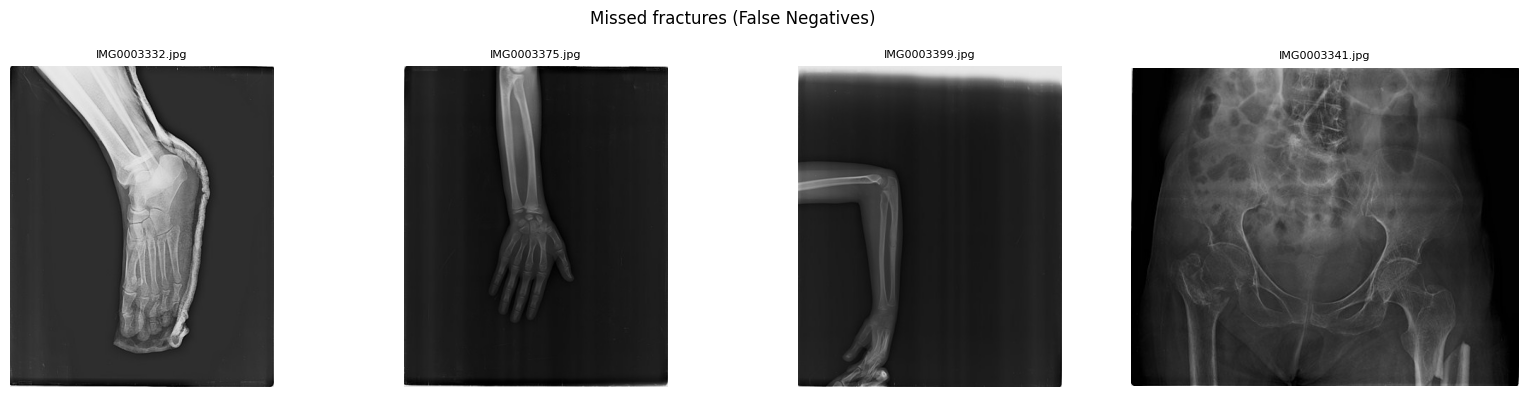

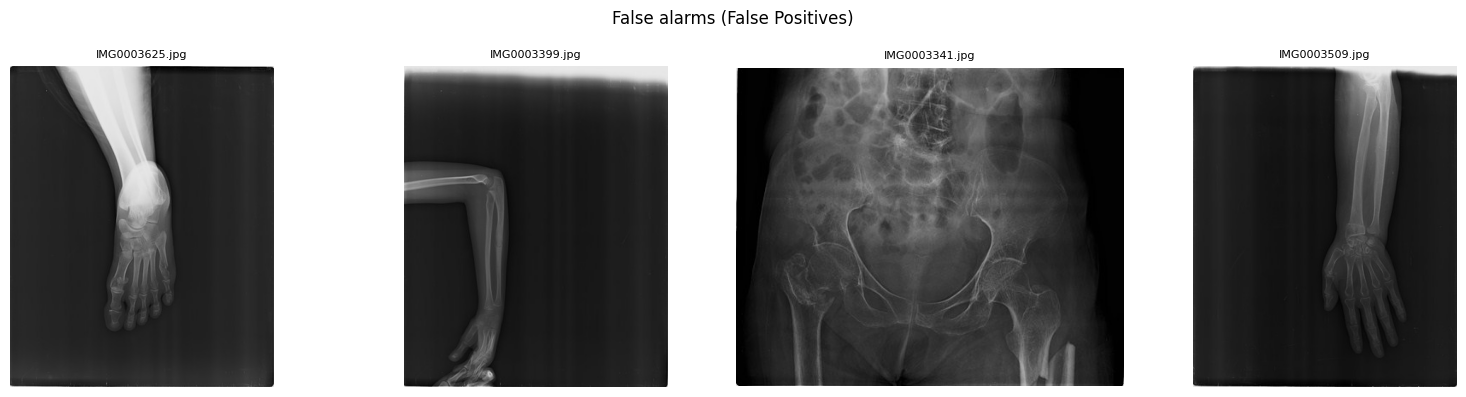

In [22]:
# Visualize a handful of false negatives and false positives so you have
# screenshots for your README / demo slide
import matplotlib.pyplot as plt

def show_examples(paths, title, n=4):
    paths = list(dict.fromkeys(paths))[:n]  # dedupe, keep order
    if not paths:
        print(f"No examples for: {title}")
        return
    fig, axes = plt.subplots(1, len(paths), figsize=(4*len(paths), 4))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples([p for p, _ in false_negatives], "Missed fractures (False Negatives)")
show_examples(false_positives, "False alarms (False Positives)")


## 13. Summary table for your README / resume talking points



In [23]:
print("=" * 60)
print("PROJECT SUMMARY -- Fracture Detection & Localization (YOLOv8)")
print("=" * 60)
print(f"Dataset: FracAtlas, {n_images} train images, "
      f"~1:{(n_images-n_with_boxes)/max(n_with_boxes,1):.1f} class imbalance (fracture:non-fracture)")
print(f"Imbalance handling: 3x oversampling of positive class + mosaic/mixup/copy-paste augmentation")
print(f"Small-object mitigation: trained at imgsz=1024 (up from 640) + copy-paste augmentation")
print(f"Statistical rigor: each variant trained across {len(SEEDS)} seeds, compared via mean +/- std")
print()
print("Model comparison (test set, mean +/- std across seeds):")
print(comparison.to_string(index=False))
print()
print(f"Best model (by mean mAP@0.5): {'CLAHE + Denoising variant' if use_clahe else 'Baseline'}")
print(f"Inference latency (baseline, seed=42): {lat_baseline.mean()*1000:.1f} ms +/- {lat_baseline.std()*1000:.1f} ms, {1/lat_baseline.mean():.1f} FPS")
print(f"Inference latency (CLAHE, seed=42):    {lat_clahe.mean()*1000:.1f} ms +/- {lat_clahe.std()*1000:.1f} ms, {1/lat_clahe.mean():.1f} FPS")
print()
print(f"Error analysis (conf={CONF_THRESHOLD}, IoU match={IOU_THRESHOLD_FOR_MATCH}): "
      f"{true_positives} TP, {len(false_positives)} FP, {len(false_negatives)} FN")
if len(fn_areas):
    print(f"Missed fractures skew small/hairline: {small_fn} small vs {large_fn} large "
          f"({100*small_fn/max(len(fn_areas),1):.0f}% of misses are small-bbox cases)")


PROJECT SUMMARY -- Fracture Detection & Localization (YOLOv8)
Dataset: FracAtlas, 1148 train images, ~1:1.0 class imbalance (fracture:non-fracture)
Imbalance handling: 3x oversampling of positive class + mosaic/mixup/copy-paste augmentation
Small-object mitigation: trained at imgsz=1024 (up from 640) + copy-paste augmentation
Statistical rigor: each variant trained across 3 seeds, compared via mean +/- std

Model comparison (test set, mean +/- std across seeds):
      Metric Baseline (mean +/- std) CLAHE (mean +/- std)   Delta                                   Verdict
     mAP@0.5       0.5167 +/- 0.0413    0.4571 +/- 0.0058 -0.0596                           Real difference
mAP@0.5:0.95       0.2183 +/- 0.0198    0.1801 +/- 0.0083 -0.0382                           Real difference
   Precision       0.7058 +/- 0.0583    0.5965 +/- 0.0659 -0.1094 Within noise -- not a reliable difference
      Recall       0.4493 +/- 0.0516    0.4225 +/- 0.0294 -0.0268 Within noise -- not a reliable diff